EDA :

Feature/Label Seperation

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/processed/processed_data.csv")

X=df.drop(['Label','Binary_Label'],axis=1)
y=df["Binary_Label"]

print(X.shape)
print(y.shape)

(2018473, 70)
(2018473,)


Class Distribution

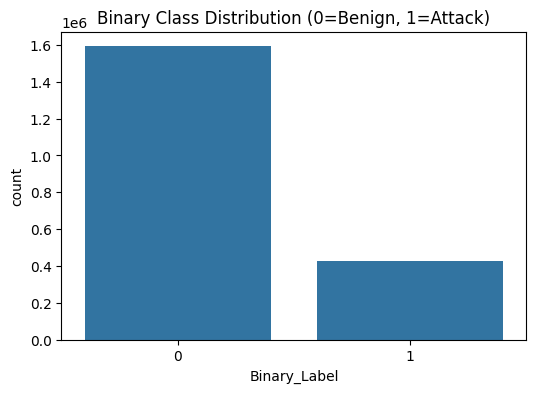

Binary_Label
0    78.907768
1    21.092232
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Binary Class Distribution (0=Benign, 1=Attack)")
plt.show()

print(y.value_counts(normalize=True)*100)

Statistical summary (mean,median,mean_meadian_differnce,std etc..)

                                     mean   median           std   min  \
Destination Port             8.071109e+03     80.0  1.820088e+04   0.0   
Flow Duration                1.799968e+07  58554.0  3.640184e+07 -13.0   
Total Fwd Packets            1.014257e+01      2.0  7.609737e+02   1.0   
Total Backward Packets       1.144271e+01      2.0  1.016693e+03   0.0   
Total Length of Fwd Packets  6.254078e+02     66.0  1.139428e+04   0.0   
Total Length of Bwd Packets  1.796214e+04    156.0  2.302887e+06   0.0   
Fwd Packet Length Max        2.390034e+02     40.0  8.134455e+02   0.0   
Fwd Packet Length Min        1.899179e+01      2.0  6.542274e+01   0.0   
Fwd Packet Length Mean       6.632668e+01     36.0  2.133450e+02   0.0   
Fwd Packet Length Std        8.149314e+01      0.0  3.231048e+02   0.0   

                                      max  mean_median_diff  
Destination Port             6.553300e+04      7.991109e+03  
Flow Duration                1.200000e+08      1.794113e+07  

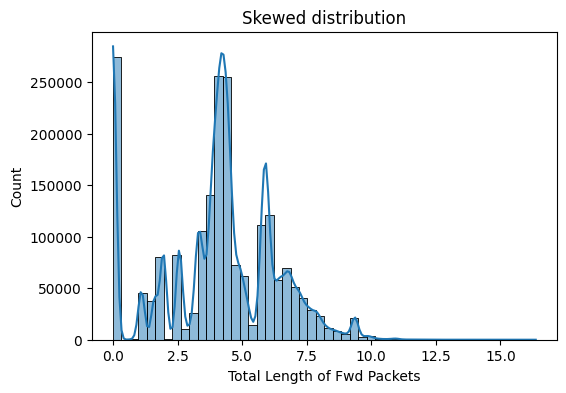

In [4]:
summary = X.describe().T
summary['median']=X.median()
summary['mean_median_diff']=summary['mean']-summary['median']

print(summary[['mean','median','std','min','max','mean_median_diff']].head(10))

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(X["Total Length of Fwd Packets"]), bins=50, kde=True)
plt.title("Skewed distribution")
plt.show()


Skewed feature detection & Log Transformation

In [ ]:
skew_values = X.skew()
highly_skewed=skew_values[skew_values>3]

print(highly_skewed.shape)
print(highly_skewed)

(44,)
Total Fwd Packets              232.429216
Total Backward Packets         232.708045
Total Length of Fwd Packets    755.796936
Total Length of Bwd Packets    233.086422
Fwd Packet Length Max            8.941395
Fwd Packet Length Min           18.358468
Fwd Packet Length Mean           8.104612
Fwd Packet Length Std            9.477476
Bwd Packet Length Min            4.883603
Flow Bytes/s                    44.246372
Flow Packets/s                   7.216739
Flow IAT Mean                    8.445276
Flow IAT Std                     3.004424
Flow IAT Min                    26.872210
Fwd IAT Mean                     6.554046
Fwd IAT Min                      9.685134
Bwd IAT Mean                     7.759137
Bwd IAT Std                      5.040104
Bwd IAT Max                      3.957441
Bwd IAT Min                      9.615116
Fwd PSH Flags                    4.415126
Fwd URG Flags                  158.833089
Fwd Packets/s                    7.608006
Bwd Packets/s               

Attack vs Normal (Feature vs Label) analysis

c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


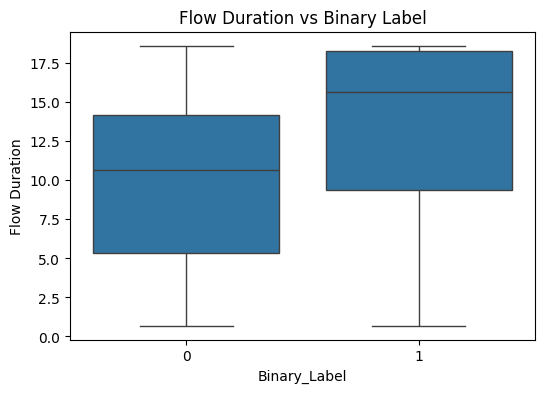

c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


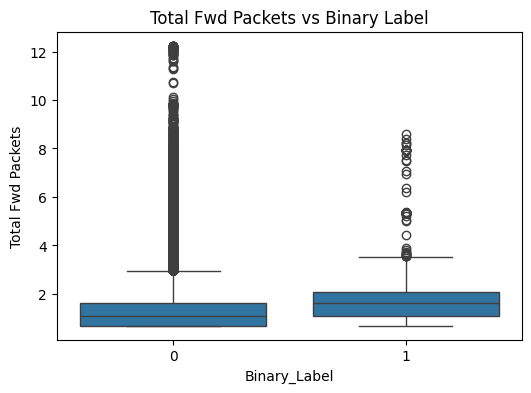

c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


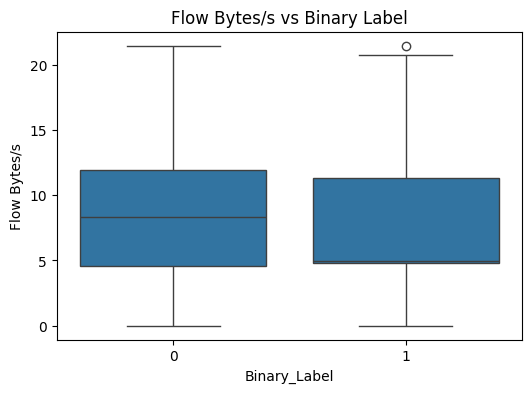

c:\Users\akank\MyCodes\Intrusion Detection System\venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


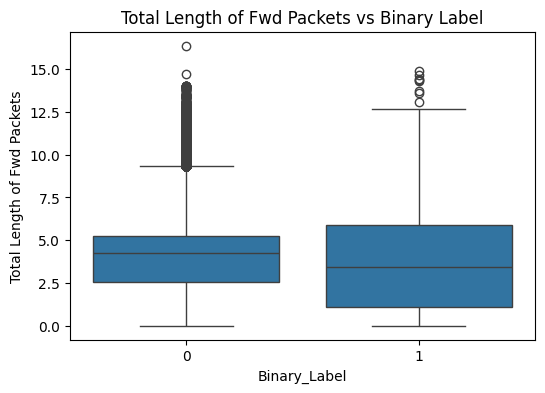

In [30]:
features = ["Flow Duration", "Total Fwd Packets", "Flow Bytes/s","Total Length of Fwd Packets"]

for col in features:
    if col in X.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=y, y=np.log1p(X[col]))
        plt.title(f"{col} vs Binary Label")
        plt.show()

Correlation Analysis

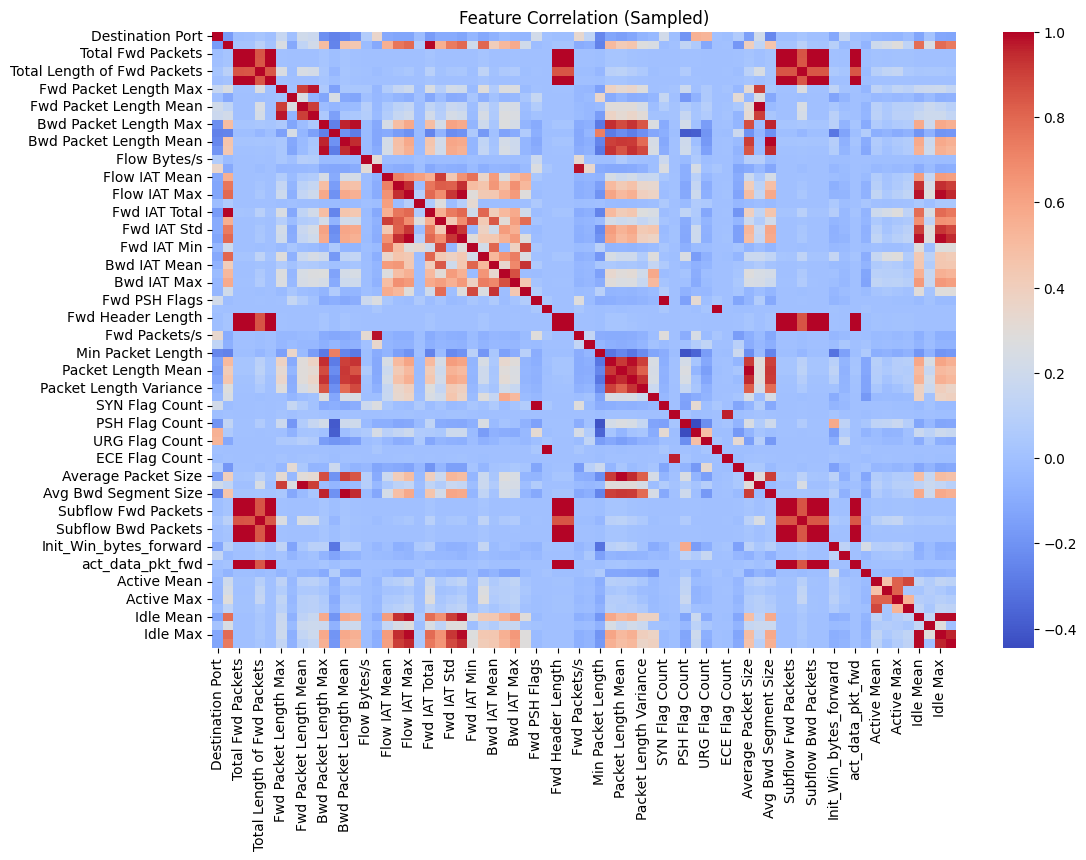

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(X.sample(50000).corr(), cmap="coolwarm")
plt.title("Feature Correlation (Sampled)")
plt.show()

Feature Importance Plot

In [32]:
# from sklearn.ensemble import RandomForestClassifier

# sample_size = 200000   # 1 lakh rows
# sample = X.sample(sample_size, random_state=42)
# y_sample = y.loc[sample.index]

# rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# rf.fit(sample,y_sample)

# importance = rf.feature_importances_
# feature_importance = pd.Series(importance, index=X.columns).sort_values(ascending=False)

# top20 = feature_importance.head(20)

# # print("Remaining features:", X_selected.shape)
# # print("Name of features:",list(X_selected.columns))

# plt.figure(figsize=(8,6))
# sns.barplot(x=top20.values, y=top20.index)
# plt.title("Top 20 Feature Importance")
# plt.show()